<a href="https://colab.research.google.com/github/kkxiong00/audio_algorithms/blob/main/wiener_filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Overview
This is a hands-on of wiener filter.

# Weiner Filter
Implementation and evaluation on Wiener filter.

First let's create a sine wave with white nise mixed.

In [ ]:
import numpy as np

# Signal parameters
frequency = 1000  # Hz
amplitude = 0.5
sample_rate = 16000  # Hz
duration = 1  # seconds

# Noise parameters
noise_covariance = 0.01 # Updated to 0.01 per request

# Generate time vector
t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)

# Generate sine wave
sine_wave = amplitude * np.sin(2 * np.pi * frequency * t)

# Generate white noise
white_noise = np.random.normal(0, np.sqrt(noise_covariance), len(t))

# Mix sine wave with white noise
signal_with_noise = sine_wave + white_noise

print(f"Generated signal with length: {len(signal_with_noise)}")
print(f"First 5 samples of mixed signal: {signal_with_noise[:5]}")

Generated signal with length: 16000
First 5 samples of mixed signal: [-0.09595483  0.10625273  0.39485196  0.60465074  0.58605941]


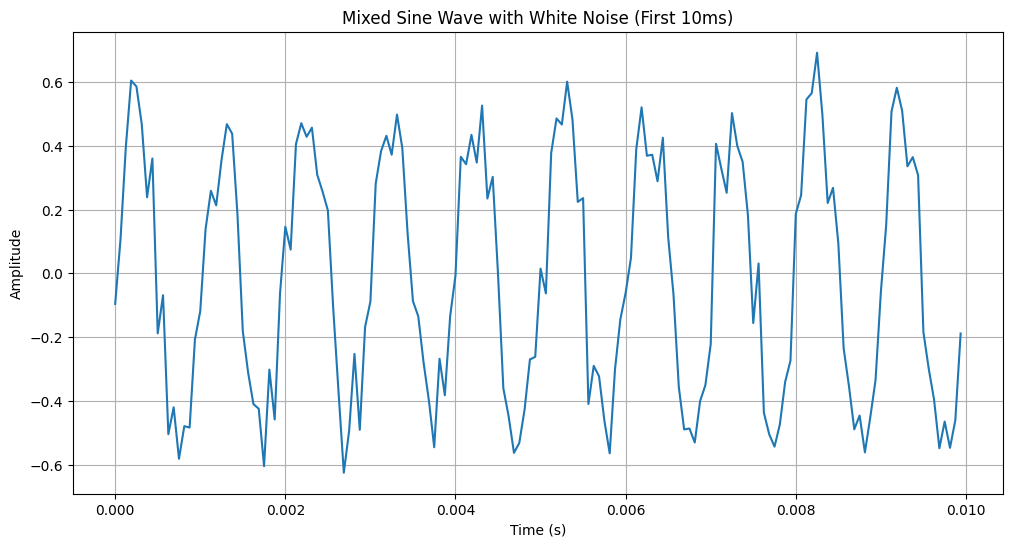

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import Audio

# Define the duration for plotting (10ms)
plot_duration = 0.01 # seconds
plot_samples = int(sample_rate * plot_duration)

# Plot the mixed signal for the first 10ms
plt.figure(figsize=(12, 6))
plt.plot(t[:plot_samples], signal_with_noise[:plot_samples])
plt.title('Mixed Sine Wave with White Noise (First 10ms)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

# Add a button to play the full 1 second mixed signal
Audio(signal_with_noise, rate=sample_rate)

Now let's implement a Wiener filter to remove the noise.

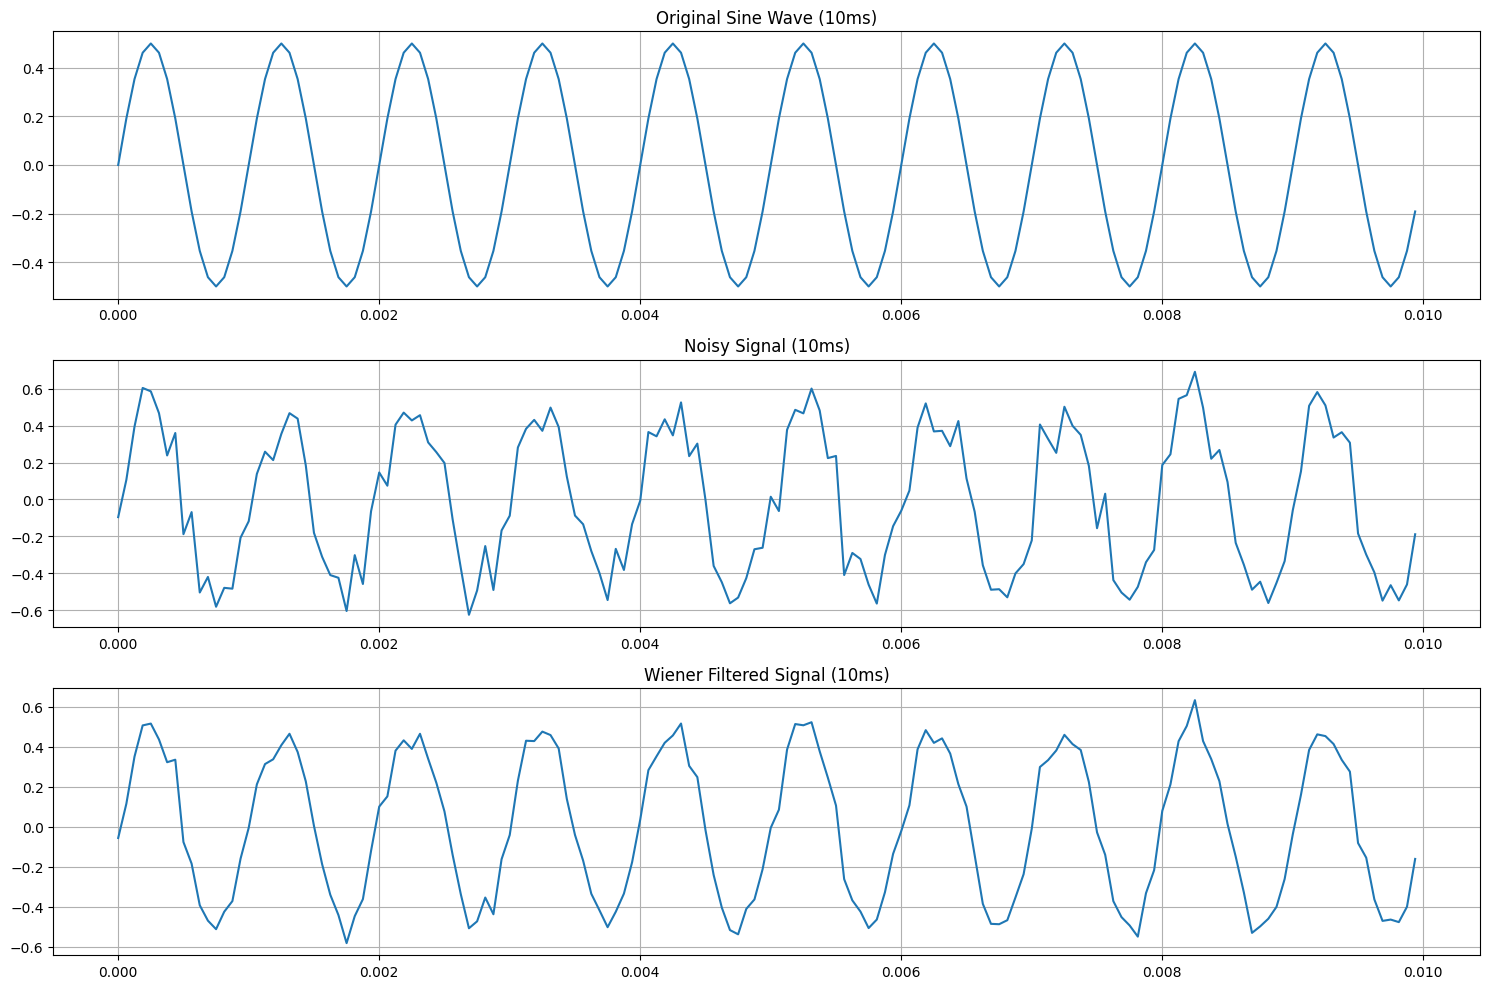

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft

# --- Step 1: Perform FFT on the noisy signal ---
N = len(signal_with_noise)
fft_noisy_signal = fft(signal_with_noise)

# --- Step 2: Estimate Power Spectral Density (PSD) of the noisy signal ---
psd_noisy = (np.abs(fft_noisy_signal)**2) / (N * sample_rate)

# --- Step 3: Estimate Power Spectral Density (PSD) of the noise ---
psd_noise_estimate = np.ones(N) * (noise_covariance / sample_rate)

# --- Step 4: Estimate the PSD of the clean signal ---
psd_signal_estimate = np.maximum(0, psd_noisy - psd_noise_estimate)

# --- Step 5: Calculate the Wiener filter gain ---
epsilon = 1e-10
wiener_gain = psd_signal_estimate / (psd_signal_estimate + psd_noise_estimate + epsilon)

# --- Step 6: Apply the filter and perform IFFT ---
fft_filtered_signal = wiener_gain * fft_noisy_signal
filtered_signal = np.real(ifft(fft_filtered_signal))

# --- Step 7: Plot the results (10ms only) ---
plot_samples_10ms = int(sample_rate * 0.01)

plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
plt.plot(t[:plot_samples_10ms], sine_wave[:plot_samples_10ms])
plt.title('Original Sine Wave (10ms)')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t[:plot_samples_10ms], signal_with_noise[:plot_samples_10ms])
plt.title('Noisy Signal (10ms)')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t[:plot_samples_10ms], filtered_signal[:plot_samples_10ms])
plt.title('Wiener Filtered Signal (10ms)')
plt.grid(True)

plt.tight_layout()
plt.show()

### SNR Calculation
We calculate the SNR as:
$$SNR_{dB} = 10 \log_{10}\left(\frac{P_{signal}}{P_{noise}}\right)$$
where $P_{noise}$ is the power of the difference between the target (original sine wave) and the resulting signal.

In [ ]:
def calculate_snr(signal, reference):
    signal_power = np.mean(reference**2)
    noise_power = np.mean((reference - signal)**2)
    return 10 * np.log10(signal_power / noise_power)

snr_before = calculate_snr(signal_with_noise, sine_wave)
snr_after = calculate_snr(filtered_signal, sine_wave)

print(f"SNR before filtering: {snr_before:.2f} dB")
print(f"SNR after filtering: {snr_after:.2f} dB")
print(f"Improvement: {snr_after - snr_before:.2f} dB")

SNR before filtering: 11.07 dB
SNR after filtering: 17.74 dB
Improvement: 6.67 dB


### Frequency Spectrum Visualization
We can visualize the effect of the filter in the frequency domain. The plot below shows the magnitude spectrum of the noisy signal versus the filtered signal.

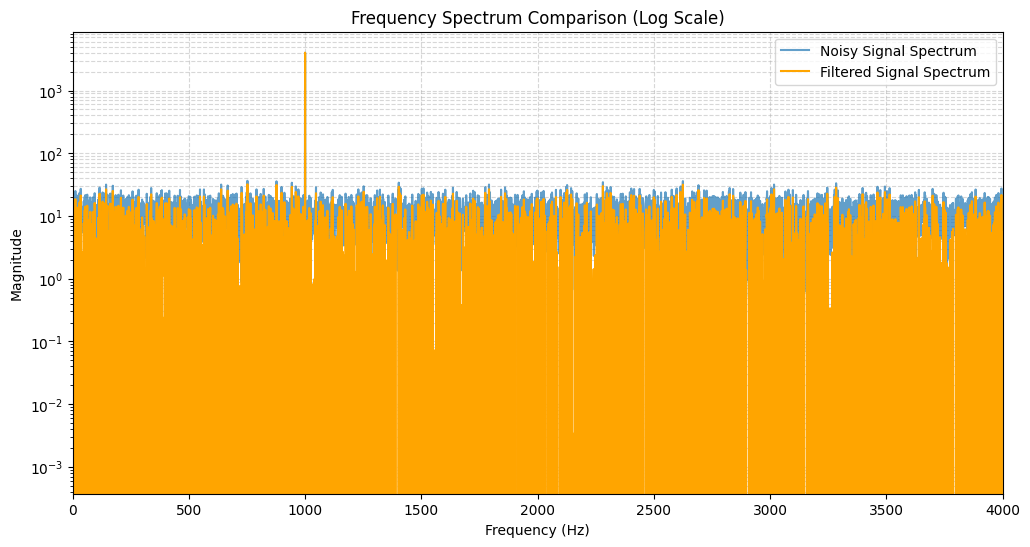

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate frequency axis
freqs = np.fft.fftfreq(N, 1/sample_rate)

# Only take the positive frequencies for plotting
pos_mask = freqs >= 0
plot_freqs = freqs[pos_mask]

# Magnitude spectra
mag_noisy = np.abs(fft_noisy_signal[pos_mask])
mag_filtered = np.abs(fft_filtered_signal[pos_mask])

plt.figure(figsize=(12, 6))
plt.semilogy(plot_freqs, mag_noisy, label='Noisy Signal Spectrum', alpha=0.7)
plt.semilogy(plot_freqs, mag_filtered, label='Filtered Signal Spectrum', color='orange')

plt.title('Frequency Spectrum Comparison (Log Scale)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, 4000) # Focusing on the lower frequency range where our signal is
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

### Time-Domain Wiener Filter (Wiener-Hopf)
In the time domain, we find a set of FIR filter coefficients $w$ that minimizes the mean squared error. This is done by solving:
$$R_{xx} w = r_{dx}$$
where $R_{xx}$ is the autocorrelation matrix of the noisy signal and $r_{dx}$ is the cross-correlation vector between the desired signal and the noisy signal.

SNR (Time Domain Wiener, 128 taps):
Corrected Steady-State SNR: 8.12 dB


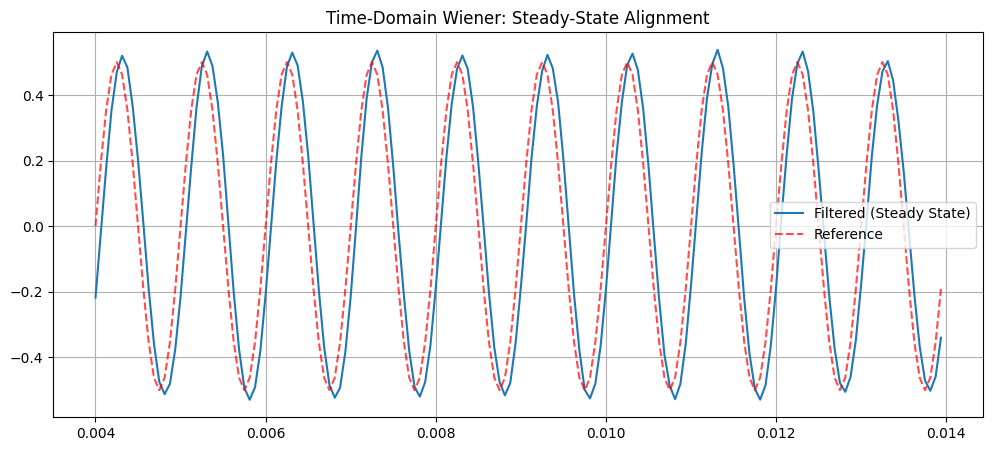

In [ ]:
from scipy.linalg import toeplitz

def time_domain_wiener(noisy, desired, tap_length=64):
    # Wiener-Hopf equation solution
    r_dx = np.correlate(desired, noisy, mode='full')
    center = len(r_dx) // 2
    r_dx = r_dx[center:center + tap_length] / len(noisy)

    r_xx_full = np.correlate(noisy, noisy, mode='full')
    r_xx = r_xx_full[center:center + tap_length] / len(noisy)

    R_xx = toeplitz(r_xx)
    w = np.linalg.solve(R_xx, r_dx)

    # 'same' mode centers the filter response within the output array
    filtered = np.convolve(noisy, w, mode='same')
    return filtered, w

tap_len = 128
filtered_time, weights = time_domain_wiener(signal_with_noise, sine_wave, tap_length=tap_len)

# --- Corrected Alignment & Evaluation ---
# In 'same' mode, the transient effects occur at the beginning and end.
# We crop half the tap length from both ends to evaluate the steady state.
half_tap = tap_len // 2

signal_steady = filtered_time[half_tap : -half_tap]
reference_steady = sine_wave[half_tap : -half_tap]

snr_time_corrected = calculate_snr(signal_steady, reference_steady)

print(f"SNR (Time Domain Wiener, {tap_len} taps):")
print(f"Corrected Steady-State SNR: {snr_time_corrected:.2f} dB")

# Visualization of the steady-state overlap
plt.figure(figsize=(12, 5))
plt.plot(t[half_tap:half_tap+160], signal_steady[:160], label='Filtered (Steady State)')
plt.plot(t[half_tap:half_tap+160], reference_steady[:160], 'r--', alpha=0.7, label='Reference')
plt.title('Time-Domain Wiener: Steady-State Alignment')
plt.legend()
plt.grid(True)
plt.show()

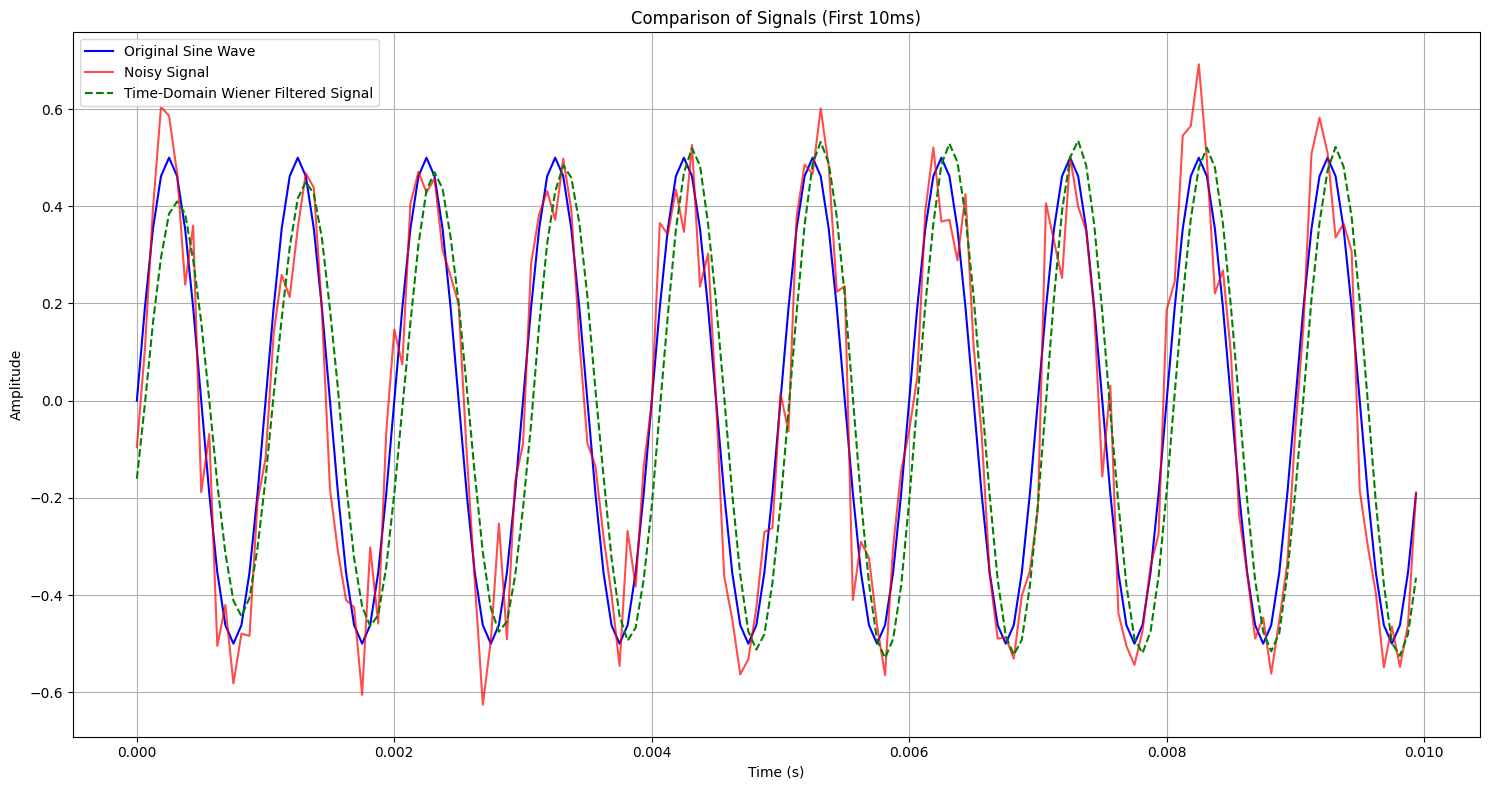

In [ ]:
import matplotlib.pyplot as plt

# Define the duration for plotting (e.g., 10ms) for better visualization
plot_duration_ms = 10 # milliseconds
plot_samples_compare = int(sample_rate * (plot_duration_ms / 1000.0))

plt.figure(figsize=(15, 8))

plt.plot(t[:plot_samples_compare], sine_wave[:plot_samples_compare], label='Original Sine Wave', color='blue')
plt.plot(t[:plot_samples_compare], signal_with_noise[:plot_samples_compare], label='Noisy Signal', color='red', alpha=0.7)
plt.plot(t[:plot_samples_compare], filtered_time[:plot_samples_compare], label='Time-Domain Wiener Filtered Signal', color='green', linestyle='--')

plt.title(f'Comparison of Signals (First {plot_duration_ms}ms)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Step-by-Step Alignment and SNR Recalculation
To fix the alignment, we identify the lag that maximizes the cross-correlation between the filtered output and the reference, then shift the signals accordingly.

Detected lag: 1 samples
Corrected SNR after precise alignment: 26.54 dB


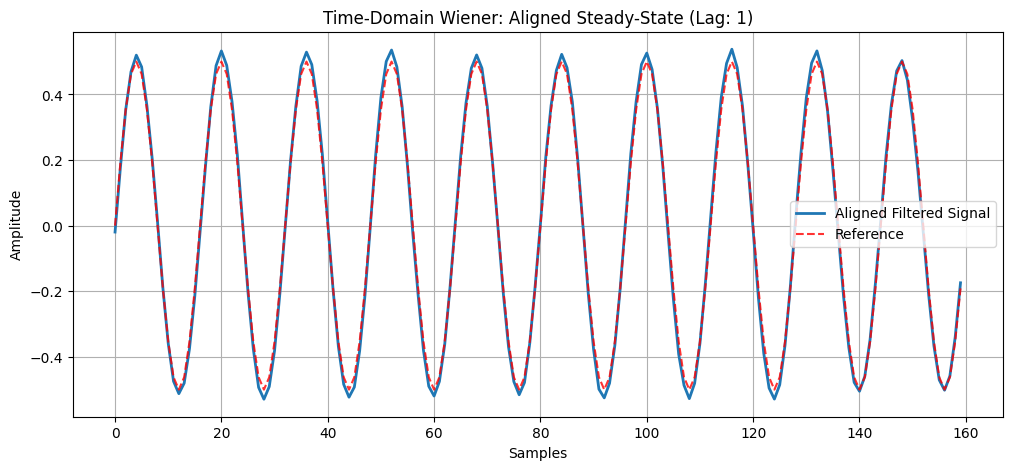

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Find the lag using cross-correlation
correlation = np.correlate(signal_steady - np.mean(signal_steady),
                           reference_steady - np.mean(reference_steady),
                           mode='full')
lags = np.arange(-len(signal_steady) + 1, len(signal_steady))
best_lag = lags[np.argmax(correlation)]

print(f"Detected lag: {best_lag} samples")

# 2. Align the signals based on the detected lag
if best_lag > 0:
    # Signal is delayed relative to reference
    aligned_signal = signal_steady[best_lag:]
    aligned_reference = reference_steady[:-best_lag]
elif best_lag < 0:
    # Signal is advanced relative to reference
    aligned_signal = signal_steady[:best_lag]
    aligned_reference = reference_steady[-best_lag:]
else:
    aligned_signal = signal_steady
    aligned_reference = reference_steady

# 3. Recalculate SNR
snr_aligned = calculate_snr(aligned_signal, aligned_reference)
print(f"Corrected SNR after precise alignment: {snr_aligned:.2f} dB")

# 4. Visualization of the corrected alignment
plt.figure(figsize=(12, 5))
plt.plot(aligned_signal[:160], label='Aligned Filtered Signal', linewidth=2)
plt.plot(aligned_reference[:160], 'r--', label='Reference', alpha=0.8)
plt.title(f'Time-Domain Wiener: Aligned Steady-State (Lag: {best_lag})')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()